In [50]:
## Day 7
## Block 1
import pandas as pd
df=pd.read_csv("House_price_train.csv")
df.head()
# df.shape
# df.info()
# missing = df.isnull().sum().sort_values(ascending=False)
# # print(missing)
# miss = missing[missing>0]
# miss
# df['PoolQC'].value_counts()

## Missing percentage
missing_percent = (df.isnull().sum())/len(df)
missing_percent = missing_percent[missing_percent>0].sort_values(ascending=False)
# print(missing_percent*100)

## Block 3
## Visualisation missing

# import seaborn as sns
# import matplotlib.pyplot as plt
# plt.figure(figsize=(12,6))
# sns.heatmap(df.isnull(),cbar=False)
# plt.show()

## Block 4
# decide drop vs keep

# Rule 1 = drop very high missing>80%
col_to_drop = missing_percent[missing_percent>0.80].index
# print(col_to_drop)
df.drop(columns=col_to_drop,inplace=True)
df.head()

# Block 5

## First cleaning step
## Fill Categorical Missing
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna('None')

# Fill Numeric
num_cols= df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
MasVnrType       0
MasVnrArea       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinSF1       0
BsmtFinType2     0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
KitchenQual 

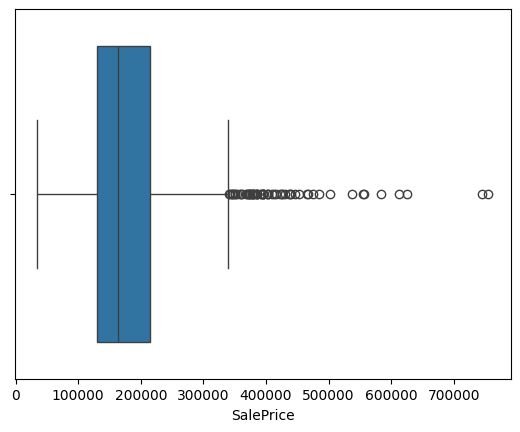

In [53]:
## Hour 2

## Outlier Detection
df["SalePrice"].describe()

#Block 2
# Boxplot
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=df["SalePrice"])
plt.show()


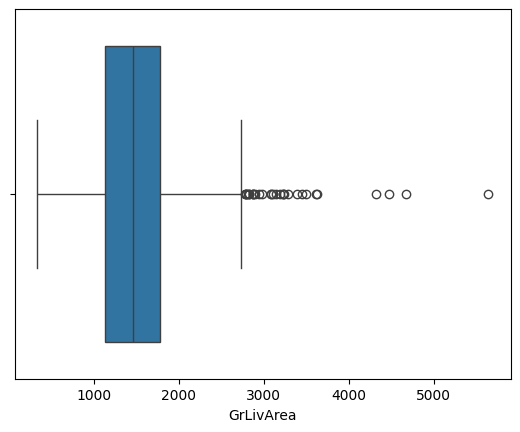

In [54]:
# Boxplot for GrLivArea
sns.boxplot(x=df['GrLivArea'])
plt.show()

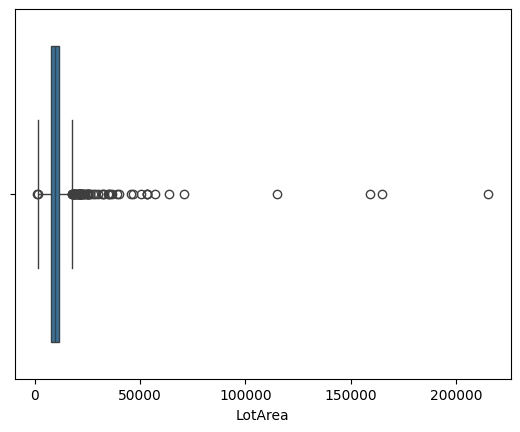

In [55]:
# Boxplot for LotArea
sns.boxplot(x=df['LotArea'])
plt.show()

In [61]:
## Block 3

## IQR Method
Q1 = df["SalePrice"].quantile(0.25)
Q3 = df["SalePrice"].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

# # Detect Outlier on SalePrice
# outliers_sale_price = df[(df["SalePrice"]<lower) | (df["SalePrice"]>upper)]
# outliers_sale_price.shape

## detect outlier on GrLivArea
# Q1 = df["GrLivArea"].quantile(0.25)
# Q3 = df["GrLivArea"].quantile(0.75)
# IQR = Q3-Q1
# lower = Q1-1.5*IQR
# upper = Q3+1.5*IQR
# outlier_GrLivArea = df[(df["GrLivArea"]<lower) | (df["GrLivArea"]>upper)]
# outlier_GrLivArea.shape

## Block 4
## Scatter Plot
# plt.scatter(df['GrLivArea'], df['SalePrice'])
# plt.xlabel('GrLivArea')
# plt.ylabel('SalePrice')
# plt.show()


## Block 5
## Remove Outlier based on a number - that must be jugded carefully
df = df[df["GrLivArea"]<4000]
## Removing Outlier using IQR
df = df[(df["SalePrice"]>=lower) & (df["SalePrice"]<=upper)]

In [ ]:
## Hour 3
## Block 3
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))
## Zero Filling
df["MasVnrArea"].fillna(0,inplace= True)

## Mode for Categorical
df['Electrical'].fillna(df['Electrical'].mode()[0], inplace=True)

## Domain-based fill
df['GarageYrBlt'].fillna(0, inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16672\4207313850.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["MasVnrArea"].fillna(0,inplace= True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16672\4207313850.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [ ]:
## Block 4

## Categorical Columns 

cols = ['GarageType', 'GarageFinish', 'GarageQual']
df[cols] = df[cols].fillna('None')
## Block 5
df.isnull().sum().sort_values(ascending=False)

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
MasVnrType       0
MasVnrArea       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinSF1       0
BsmtFinType2     0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
KitchenQual 

In [121]:
## Hour 4
## Block 1

## Boolean Indexing
df[(df["SalePrice"]>200000) & (df['GrLivArea']>1500)]
df[(df['SalePrice']>300000) & (df["GrLivArea"]>2000)]

## Block 2

df.loc[0:4,["SalePrice","GrLivArea"]]
df.iloc[0:5,0:3]
## First 10 rows
df.iloc[:10,:]
df[["SalePrice","Neighborhood"]]
df.head()

## Block 3
df.loc[df['SalePrice'] > 300000, ['SalePrice', 'Neighborhood']]

df.loc[df["SalePrice"] >300000,"Luxury"] = 1
df[["SalePrice","Luxury"]]

## Create new column if Luxury = 1 if price>300k else 0
df["Luxury"]=0
df.loc[df["SalePrice"]>300000, "Luxury"]=1
df["Luxury"] = df["SalePrice"].apply(lambda x: 1 if x>300000 else 0) 

## Block 4
## isin() - Multi-Value Filtering
df[df["Neighborhood"].isin(['NAmes',"CollgCr"])]

## Block 5 - Query Method

df.query("SalePrice>300000 and GrLivArea>2000")
df.query("SalePrice>329000") 

## Block 5 - Assignand Apply 
df["price_per_sqft"] = df['SalePrice']/df['GrLivArea']
df.head()

## Apply Function
df['HighPrice'] = df['SalePrice'].apply(lambda x: 1 if x>200000 else 0)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Luxury,price_per_sqft,HighPrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,2,2008,WD,Normal,208500,0,121.929825,1
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,5,2007,WD,Normal,181500,0,143.819334,0
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,9,2008,WD,Normal,223500,0,125.139978,1
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,0,0,2,2006,WD,Abnorml,140000,0,81.537566,0
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,12,2008,WD,Normal,250000,0,113.739763,1


In [ ]:
## Hour 5

## block 1
## Q1 - Average House Price
df['SalePrice'].mean()
df['SalePrice'].max()
df['SalePrice'].min()

## Block 2
df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)

## Block 3
df[['GrLivArea','SalePrice']].corr()

,GrLivArea,SalePrice
GrLivArea,1.000000,0.691535
SalePrice,0.691535,1.000000


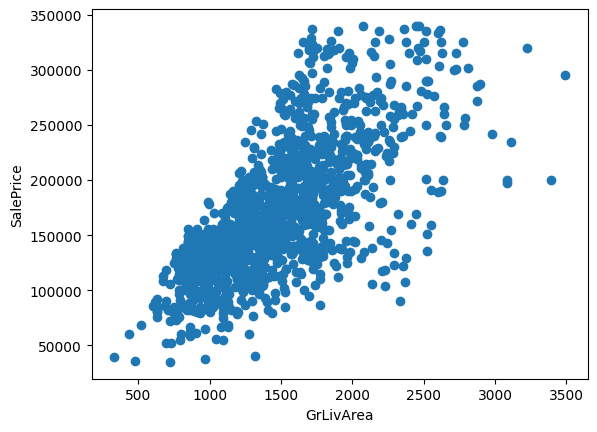

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,price_per_sqft,HighPrice
Luxury,,,,,,,,,,,,,,,,,,,,,
0,1343,1343,1343,1343,1343,1343,1343,1343,1343,1343,...,1343,1343,1343,1343,1343,1343,1343,1343,1343,1343
1,54,54,54,54,54,54,54,54,54,54,...,54,54,54,54,54,54,54,54,54,54


In [132]:
import matplotlib.pyplot as plt

plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()

df['Luxury'].value_counts()
df.groupby('Luxury')['SalePrice'].mean()
df.groupby('Luxury').count()

In [133]:
## Block 5
df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

SalePrice         1.000000
HighPrice         0.815176
OverallQual       0.789727
GrLivArea         0.691535
GarageCars        0.628516
GarageArea        0.613286
TotalBsmtSF       0.583777
FullBath          0.578700
YearBuilt         0.565147
1stFlrSF          0.549410
YearRemodAdd      0.541639
Luxury            0.505018
price_per_sqft    0.487678
GarageYrBlt       0.476272
TotRmsAbvGrd      0.475976
Fireplaces        0.455847
MasVnrArea        0.355164
OpenPorchSF       0.330594
2ndFlrSF          0.318218
LotFrontage       0.312368
BsmtFinSF1        0.310329
WoodDeckSF        0.302520
HalfBath          0.279091
LotArea           0.255023
BsmtUnfSF         0.222693
BsmtFullBath      0.203163
BedroomAbvGr      0.201612
ScreenPorch       0.108874
MoSold            0.070142
PoolArea          0.053291
3SsnPorch         0.043331
BsmtFinSF2        0.007170
Id               -0.011741
MiscVal          -0.012868
BsmtHalfBath     -0.018816
YrSold           -0.028125
OverallCond      -0.047989
L

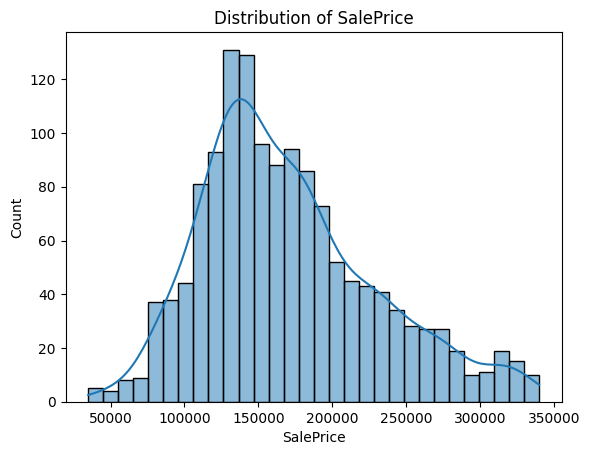

In [ ]:
## Hour 6
## Block 1
## Distribution of SalePrice
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['SalePrice'], bins=30, kde=True)
plt.title("Distribution of SalePrice")
plt.show()

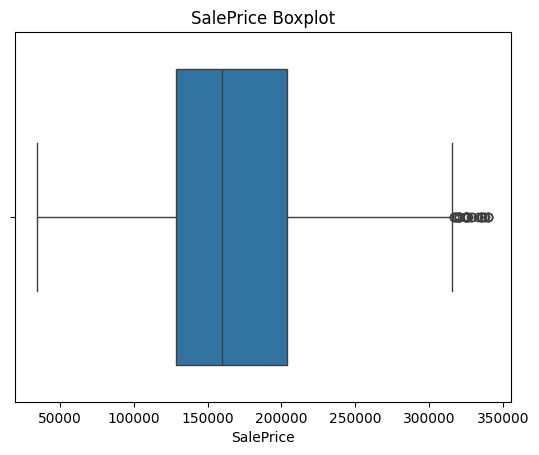

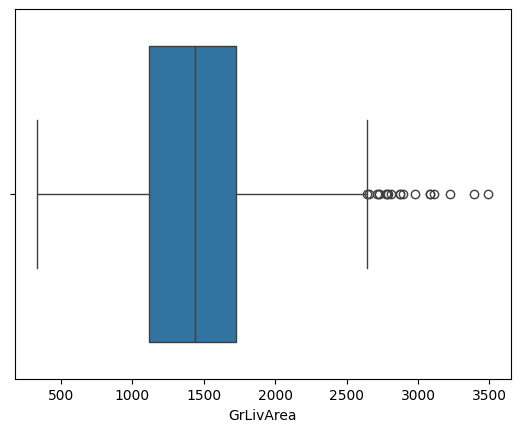

In [143]:
## Block 2
## Outlier Visualisation

## SalePrice
sns.boxplot(x=df['SalePrice'])
plt.title("SalePrice Boxplot")
plt.show()

## GrLivArea
sns.boxplot(x=df['GrLivArea'])
plt.show()

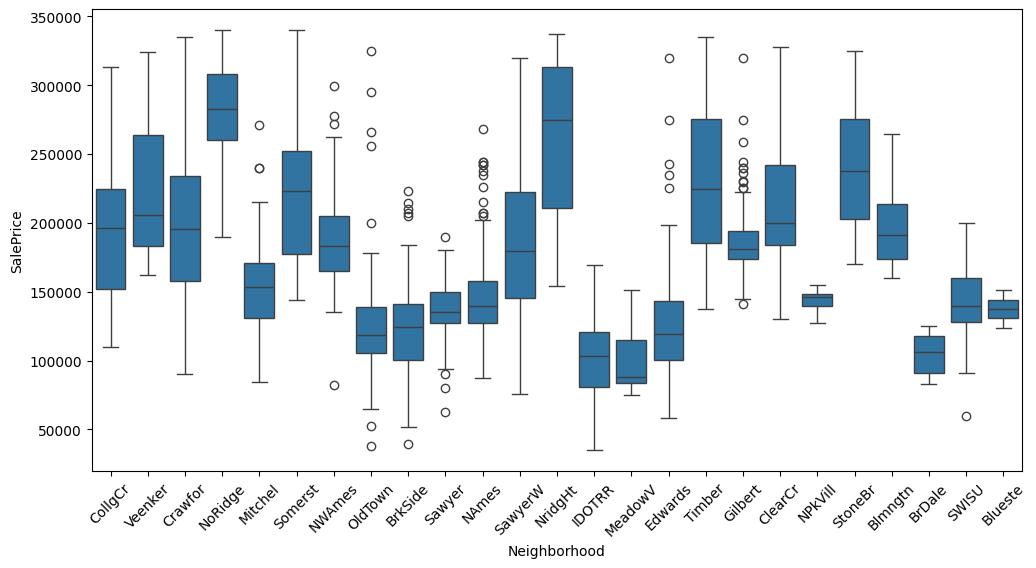

In [144]:
## Block 3
plt.figure(figsize=(12,6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df)
plt.xticks(rotation=45)
plt.show()

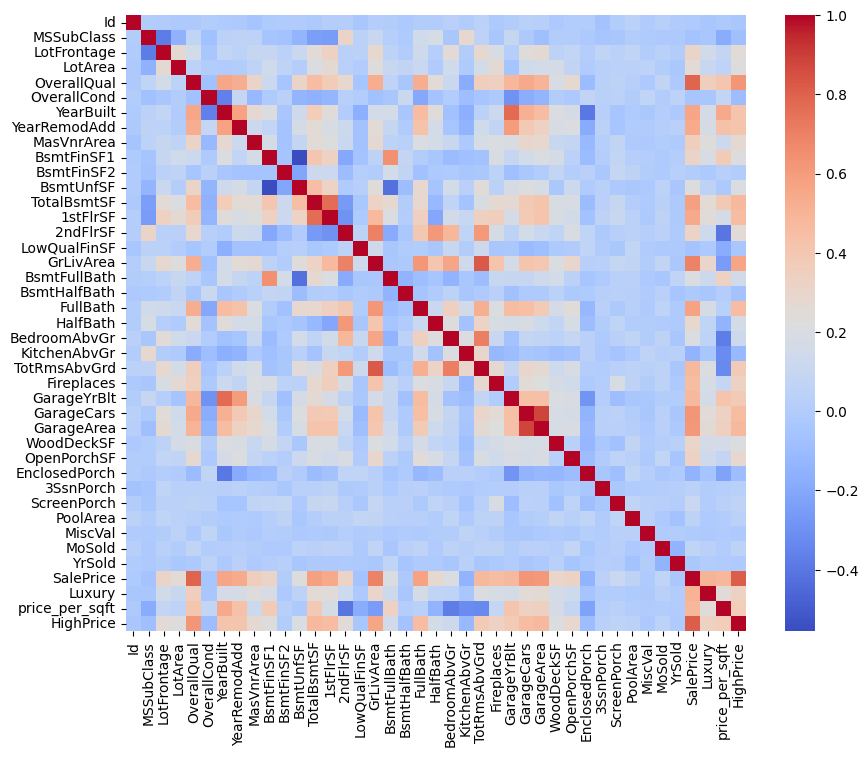

In [145]:
## Block 4
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

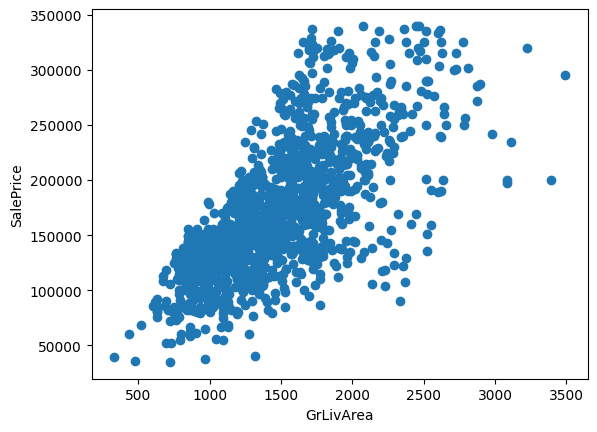

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Luxury,price_per_sqft,HighPrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,2,2008,WD,Normal,208500,0,121.929825,1
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,5,2007,WD,Normal,181500,0,143.819334,0
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,9,2008,WD,Normal,223500,0,125.139978,1
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,0,0,2,2006,WD,Abnorml,140000,0,81.537566,0
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,12,2008,WD,Normal,250000,0,113.739763,1


In [148]:
## Block 5
## Scatter plot

plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()
df.head()

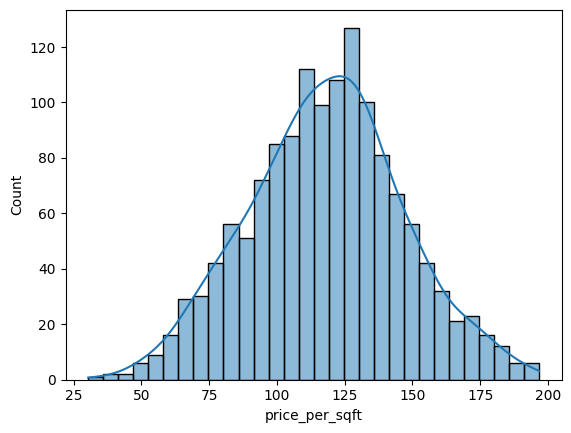

In [149]:
## Block 6
sns.histplot(df['price_per_sqft'], bins=30, kde=True)
plt.show()

In [ ]:
## Hour 7
## Block 1
## Check anagram
s1='listen'
s2='silent'
from collections import Counter
def anagram(s1,s2):
    return Counter(s1)==Counter(s2)
print(anagram(s1,s2))

True


In [175]:
## Hour 8

df=pd.read_csv('House_price_train.csv')
df.shape

## Cols to drop
missing_percent=(df.isnull().sum()/len(df))
col_to_drop=missing_percent[missing_percent>0.8].index
df.drop(columns=col_to_drop,inplace=True)
df.shape

## HAndle missing value
cat_cols = ['Alley', 'Fence', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
            'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']

for col in cat_cols:
    if col in df.columns:
        df[col].fillna('None', inplace=True)

## Numerical (Domain-Based)
df['MasVnrArea'].fillna(0, inplace=True)
df['GarageYrBlt'].fillna(0, inplace=True)

# Group Based
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

## Remainig numerical
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

## Remianing Categorical
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols]=df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

## Outlier handling
df = df[df['GrLivArea'] < 4000]

## Feature engineering
df['Luxury'] = (df['SalePrice'] > 300000).astype(int)

df['Price_per_sqft'] = df['SalePrice'] / df['GrLivArea']

## FInal checks

df.isnull().sum().sum()
df.shape
df.describe()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16672\3127129226.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('None', inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16672\3127129226.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,Luxury,Price_per_sqft
count,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.00000,1456.000000,1456.000000,1456.000000,...,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000
mean,729.967033,56.888736,69.906937,10448.784341,6.088599,5.576236,1971.18544,1984.819368,101.526786,436.991071,...,22.014423,3.418956,15.102335,2.055632,43.608516,6.326236,2007.817308,180151.233516,0.077610,120.623049
std,421.722909,42.358363,21.335081,9860.763449,1.369669,1.113966,30.20159,20.652143,177.011773,430.255052,...,61.192248,29.357056,55.828405,35.383772,496.799265,2.698356,1.329394,76696.592530,0.267649,31.213283
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.00000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000,0.000000,30.372058
25%,364.750000,20.000000,60.000000,7538.750000,5.000000,5.000000,1954.00000,1966.750000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129900.000000,0.000000,100.046809
50%,730.500000,50.000000,70.000000,9468.500000,6.000000,5.000000,1972.00000,1993.500000,0.000000,381.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000,0.000000,120.099031
75%,1094.250000,70.000000,80.000000,11588.000000,7.000000,6.000000,2000.00000,2004.000000,163.250000,706.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000,0.000000,138.588502
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.00000,2010.000000,1600.000000,2188.000000,...,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,625000.000000,1.000000,276.250881


In [176]:
df.to_csv("house_price_cleaned_v2.csv", index=False)